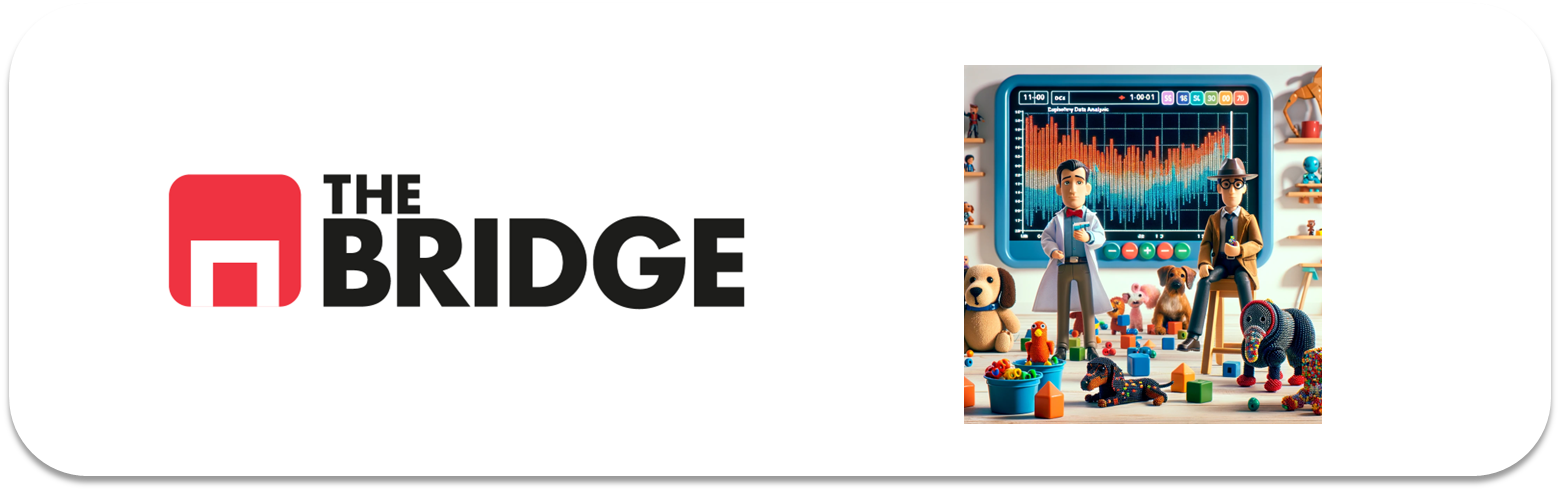

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [2]:

df_titanic=pd.read_csv("./data/titanic.csv")

In [3]:
df=df_titanic.copy()

In [4]:
display(df)
print(df.info())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB
None


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [5]:
df=df.drop(columns=["deck", "embarked", "pclass","survived"])

In [6]:
display(df)

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,0,0,13.0000,Second,man,True,Southampton,no,True
887,female,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True
888,female,NaN,1,2,23.4500,Third,woman,False,Southampton,no,False
889,male,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [7]:
df["family_members"]=df.parch+df.sibsp

In [8]:
df=df.drop(columns=["parch","sibsp"])

In [9]:
display(df)

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,13.0000,Second,man,True,Southampton,no,True,0
887,female,19.0,30.0000,First,woman,False,Southampton,yes,True,0
888,female,NaN,23.4500,Third,woman,False,Southampton,no,False,3
889,male,26.0,30.0000,First,man,True,Cherbourg,yes,True,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [10]:
moda=df.embark_town.mode()[0]
moda
df.embark_town=df.embark_town.fillna(moda)


In [11]:
print(df.embark_town.isnull().sum())

0


### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [12]:
print(df.who.unique())
print(df.who.isnull().sum())



<StringArray>
['man', 'woman', 'child']
Length: 3, dtype: str
0


In [13]:
df["age_imputed"] = df.age.isna()

# Máscaras por género
is_woman = df.who == "woman"
is_child = df.who == "child"
is_man   = df.who == "man"

# Valores medianos
mediana_woman = df.loc[is_woman, "age"].median()
mediana_child = df.loc[is_child, "age"].median()
mediana_man   = df.loc[is_man,   "age"].median()

# Imputamos
df.loc[is_woman & df["age_imputed"], "age"] = mediana_woman
df.loc[is_child & df["age_imputed"], "age"] = mediana_child
df.loc[is_man   & df["age_imputed"], "age"] = mediana_man

display(df)

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members,age_imputed
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1,False
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1,False
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0,False
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1,False
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0,False
...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,13.0000,Second,man,True,Southampton,no,True,0,False
887,female,19.0,30.0000,First,woman,False,Southampton,yes,True,0,False
888,female,30.0,23.4500,Third,woman,False,Southampton,no,False,3,True
889,male,26.0,30.0000,First,man,True,Cherbourg,yes,True,0,False


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

In [14]:
from bootcampviztools import *

# Pregunta 1.6.1

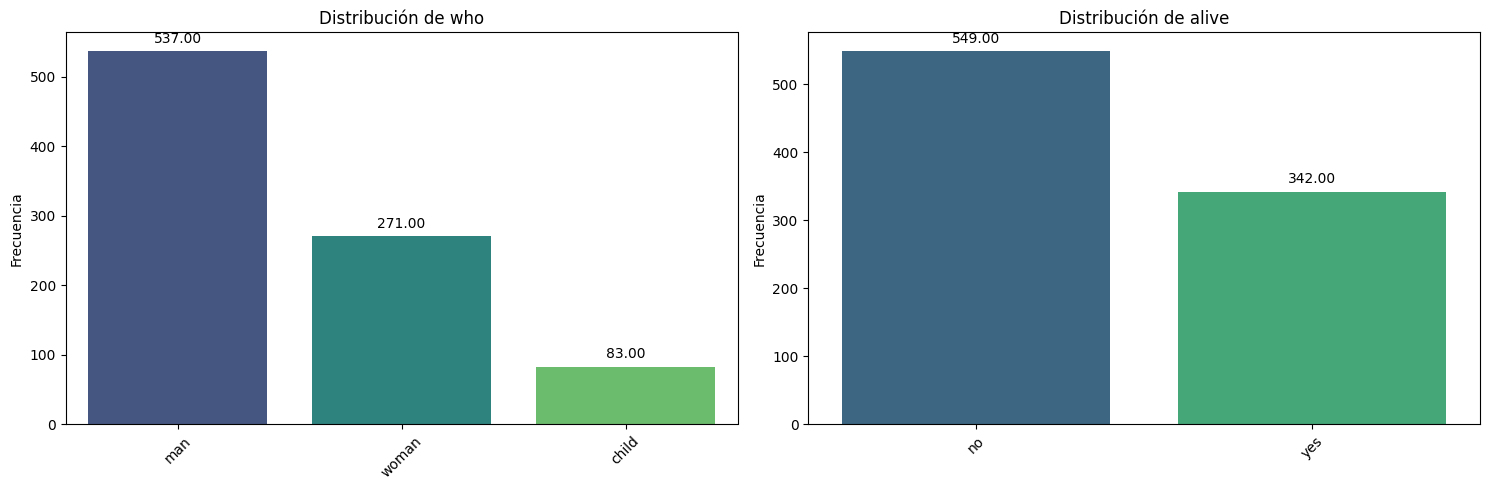

In [15]:
pinta_distribucion_categoricas(df,["who","alive"],relativa=False, mostrar_valores=True)

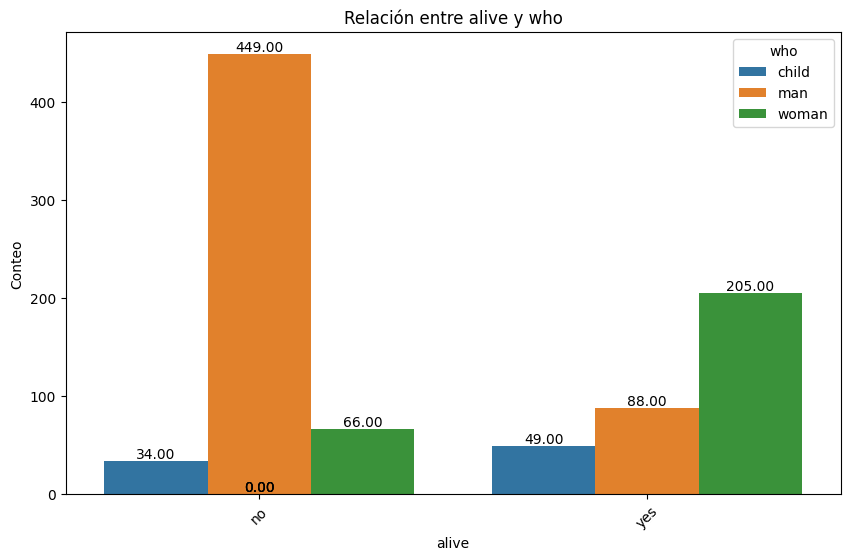

In [16]:
#1.En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?
#Absolutos
plot_categorical_relationship_fin(df,"alive","who", relative_freq=False, show_values=True)


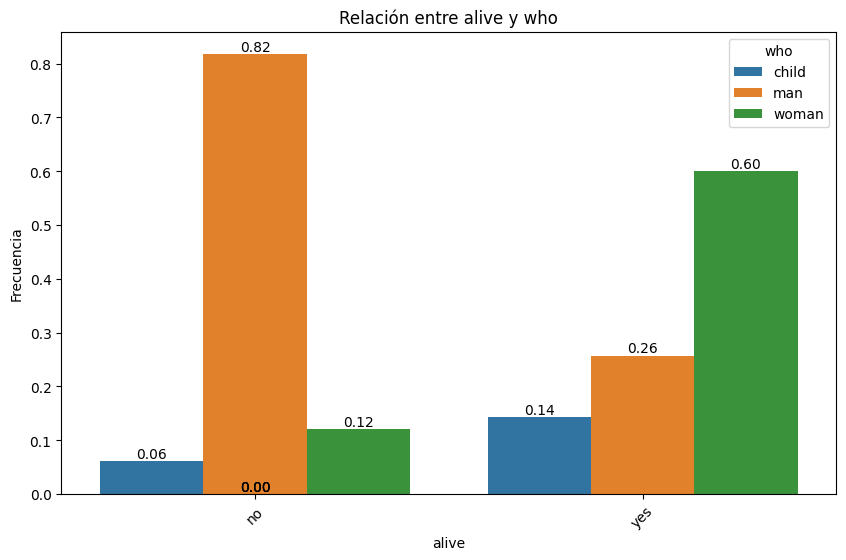

In [17]:
plot_categorical_relationship_fin(df,"alive","who", relative_freq=True, show_values=True)

In [18]:
from scipy.stats import chi2_contingency, fisher_exact

def test_chi2(df, var1, var2, alpha=0.05):
   
    tabla = pd.crosstab(df[var1], df[var2])
    print(tabla, "\n")

    chi2, p, dof, expected = chi2_contingency(tabla)
    esp = pd.DataFrame(expected, index=tabla.index, columns=tabla.columns)

    print(f"Chi-cuadrado = {chi2:.4f}")
    print(f"p-valor      = {p:.4f}")
    print(f"gl           = {dof}")
    print("Frecuencias esperadas:")
    print(esp.round(2), "\n")

    # Aviso si hay celdas con esperado < 5
    if (expected < 5).any():
        print("Aviso: hay celdas con frecuencia esperada < 5.")
        if tabla.shape == (2, 2):
            odds, p_fisher = fisher_exact(tabla)
            print(f"Se recomienda Fisher exact: p = {p_fisher:.4f}")

    if p < alpha:
        print(f"-> p < {alpha}: Rechazo H0. Las variables ESTÁN asociadas.")
    else:
        print(f"-> p >= {alpha}: No se rechaza H0. No hay evidencia de asociación.")

    return chi2, p, dof, esp


In [19]:
test_chi2(df,"alive","who")

who    child  man  woman
alive                   
no        34  449     66
yes       49   88    205 

Chi-cuadrado = 283.9231
p-valor      = 0.0000
gl           = 2
Frecuencias esperadas:
who    child     man   woman
alive                       
no     51.14  330.88  166.98
yes    31.86  206.12  104.02 

-> p < 0.05: Rechazo H0. Las variables ESTÁN asociadas.


(np.float64(283.923050324233),
 np.float64(2.2227620817798914e-62),
 2,
 who        child         man       woman
 alive                                   
 no     51.141414  330.878788  166.979798
 yes    31.858586  206.121212  104.020202)

# Pregunta 1.6.2

En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

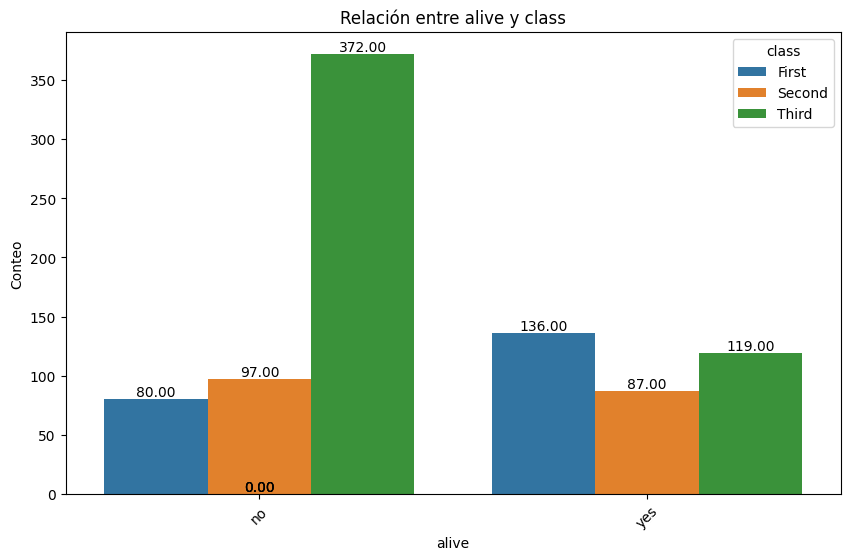

In [20]:
plot_categorical_relationship_fin(df,"alive", "class", relative_freq=False, show_values=True)

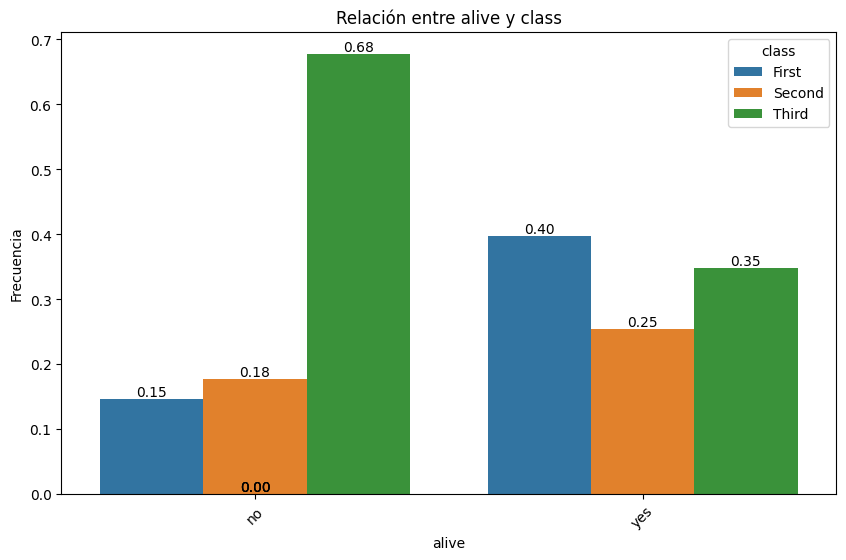

In [21]:
plot_categorical_relationship_fin(df,"alive", "class", relative_freq=True, show_values=True)

In [22]:
test_chi2(df,"alive","class")

class  First  Second  Third
alive                      
no        80      97    372
yes      136      87    119 

Chi-cuadrado = 102.8890
p-valor      = 0.0000
gl           = 2
Frecuencias esperadas:
class   First  Second   Third
alive                        
no     133.09  113.37  302.54
yes     82.91   70.63  188.46 

-> p < 0.05: Rechazo H0. Las variables ESTÁN asociadas.


(np.float64(102.88898875696056),
 np.float64(4.549251711298793e-23),
 2,
 class       First      Second       Third
 alive                                    
 no     133.090909  113.373737  302.535354
 yes     82.909091   70.626263  188.464646)

# Pregunta 1.6.3 

¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

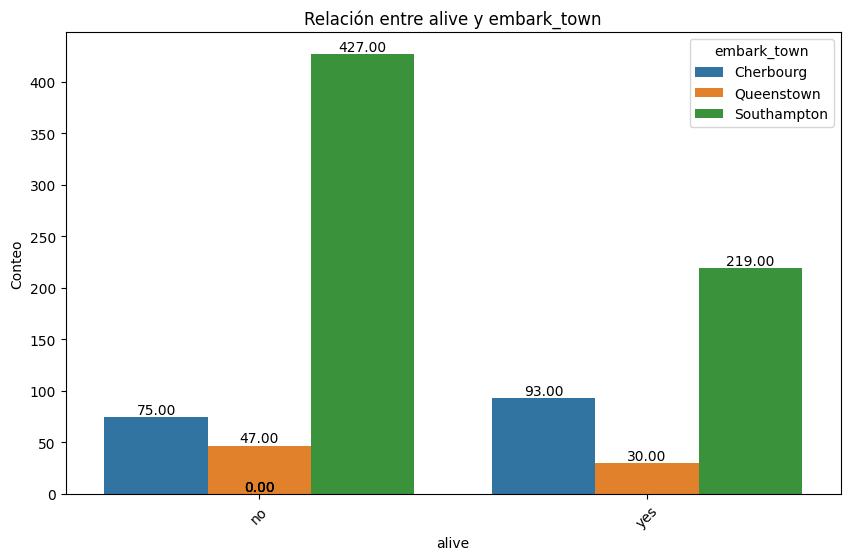

In [24]:
plot_categorical_relationship_fin(df,"alive","embark_town",relative_freq=False, show_values=True)

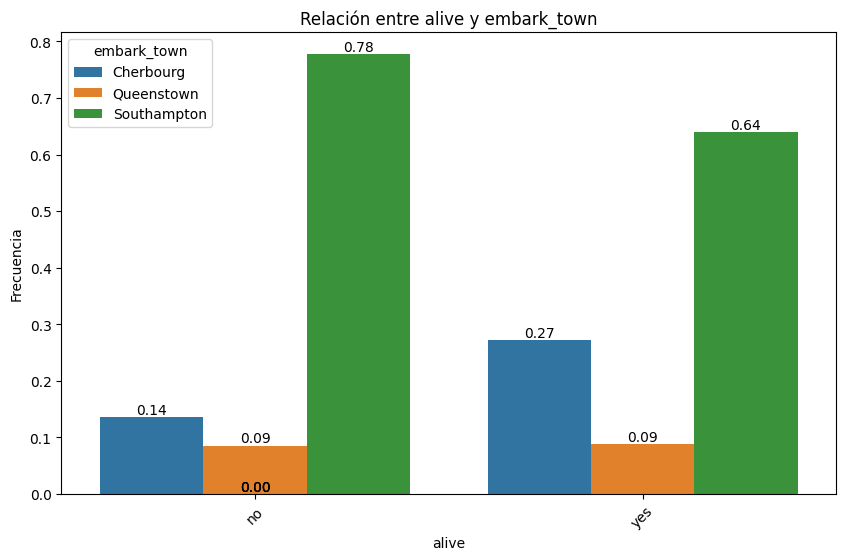

In [25]:
plot_categorical_relationship_fin(df,"alive","embark_town",relative_freq=True, show_values=True)

In [26]:
test_chi2(df,"alive","embark_town")

embark_town  Cherbourg  Queenstown  Southampton
alive                                          
no                  75          47          427
yes                 93          30          219 

Chi-cuadrado = 25.9645
p-valor      = 0.0000
gl           = 2
Frecuencias esperadas:
embark_town  Cherbourg  Queenstown  Southampton
alive                                          
no              103.52       47.44       398.04
yes              64.48       29.56       247.96 

-> p < 0.05: Rechazo H0. Las variables ESTÁN asociadas.


(np.float64(25.964452881874784),
 np.float64(2.3008626481449577e-06),
 2,
 embark_town   Cherbourg  Queenstown  Southampton
 alive                                           
 no           103.515152   47.444444   398.040404
 yes           64.484848   29.555556   247.959596)

# Pregunta 1.6.4

¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

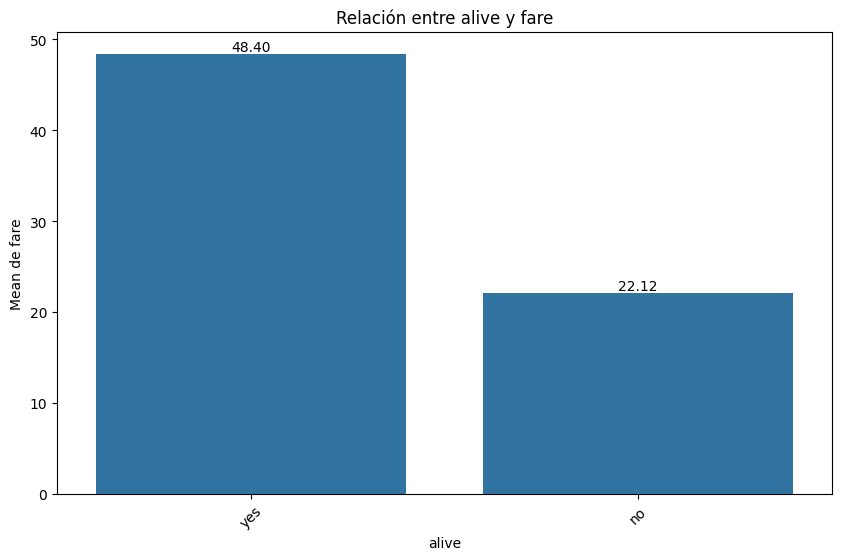

In [ ]:

plot_categorical_numerical_relationship(df,"alive","fare",show_values=True,)

In [31]:
test_chi2(df,"alive","fare")

fare   0.0000    4.0125    5.0000    6.2375    6.4375    6.4500    6.4958    \
alive                                                                         
no           14         1         1         1         1         1         2   
yes           1         0         0         0         0         0         0   

fare   6.7500    6.8583    6.9500    ...  153.4625  164.8667  211.3375  \
alive                                ...                                 
no            2         1         1  ...         1         0         0   
yes           0         0         0  ...         2         2         3   

fare   211.5000  221.7792  227.5250  247.5208  262.3750  263.0000  512.3292  
alive                                                                        
no            1         1         1         1         0         2         0  
yes           0         0         3         1         2         2         3  

[2 rows x 248 columns] 

Chi-cuadrado = 425.8084
p-valor      = 0.0000
gl

(np.float64(425.8083805791106),
 np.float64(1.1647635739939295e-11),
 247,
 fare   0.0000    4.0125    5.0000    6.2375    6.4375    6.4500    6.4958    \
 alive                                                                         
 no     9.242424  0.616162  0.616162  0.616162  0.616162  0.616162  1.232323   
 yes    5.757576  0.383838  0.383838  0.383838  0.383838  0.383838  0.767677   
 
 fare   6.7500    6.8583    6.9500    ...  153.4625  164.8667  211.3375  \
 alive                                ...                                 
 no     1.232323  0.616162  0.616162  ...  1.848485  1.232323  1.848485   
 yes    0.767677  0.383838  0.383838  ...  1.151515  0.767677  1.151515   
 
 fare   211.5000  221.7792  227.5250  247.5208  262.3750  263.0000  512.3292  
 alive                                                                        
 no     0.616162  0.616162  2.464646  1.232323  1.232323  2.464646  1.848485  
 yes    0.383838  0.383838  1.535354  0.767677  0.767677  1.5353

# Pregunta 1.6.5

Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

In [38]:
count=(df.fare==0).sum()
print(count)

15


# PRegunta 1.6.7


Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente


In [39]:
def trivariant_analysis(df, directora, cat2, num1, group_size = 3, bins = "auto"):

    col_directora = directora

    col_1 = cat2

    col_2 = num1

    diccionario_multivariante = {}

    for valor in df[col_directora].unique():

        diccionario_multivariante[valor] = df.loc[df[col_directora] == valor,[col_2,col_1]] 

 

    for valor,df_datos in diccionario_multivariante.items():

        print(f"Respuesta {valor}:")

        plot_grouped_histograms(df_datos,col_1,col_2, group_size= group_size, bins = bins)

Respuesta no:


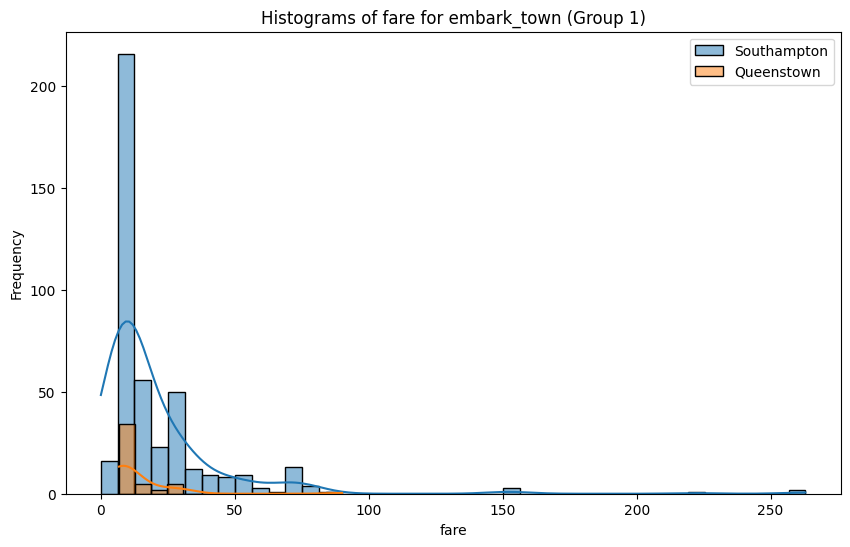

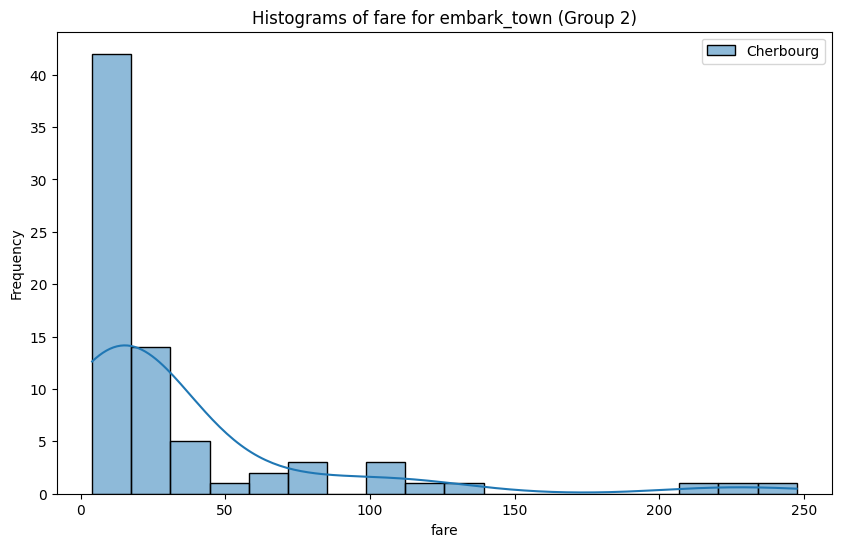

Respuesta yes:


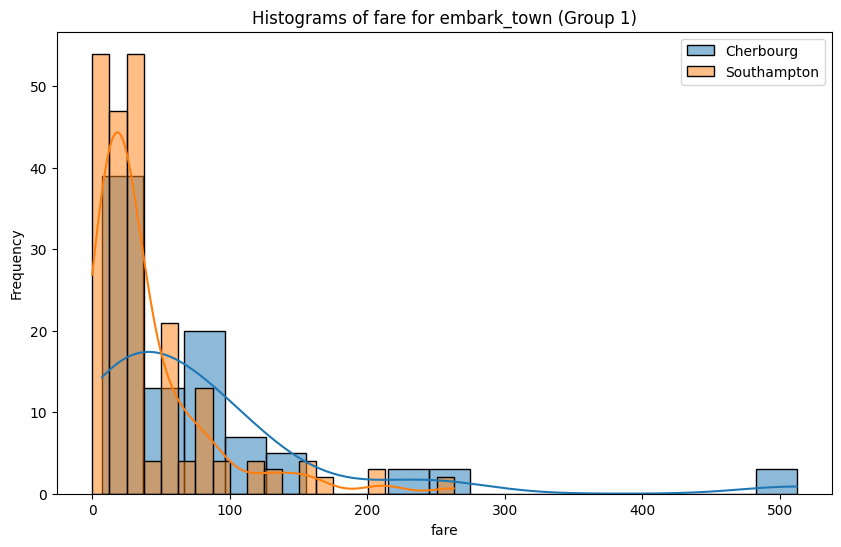

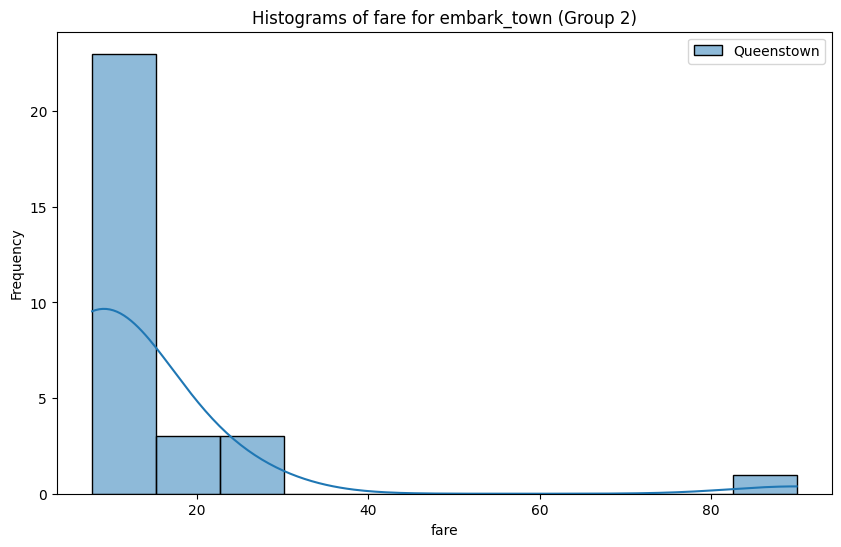

In [46]:
trivariant_analysis(df,"alive","embark_town","fare",group_size=2)

# PRegunta 1.6.7

Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

Respuesta no:


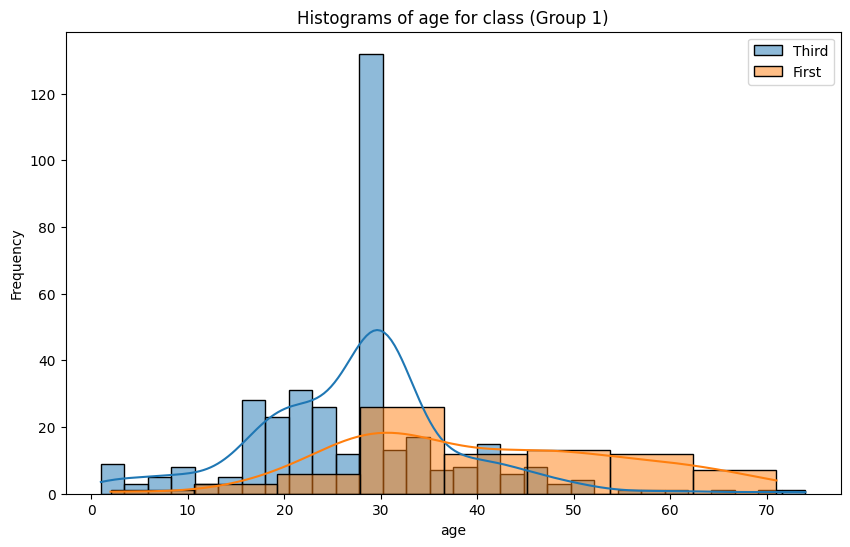

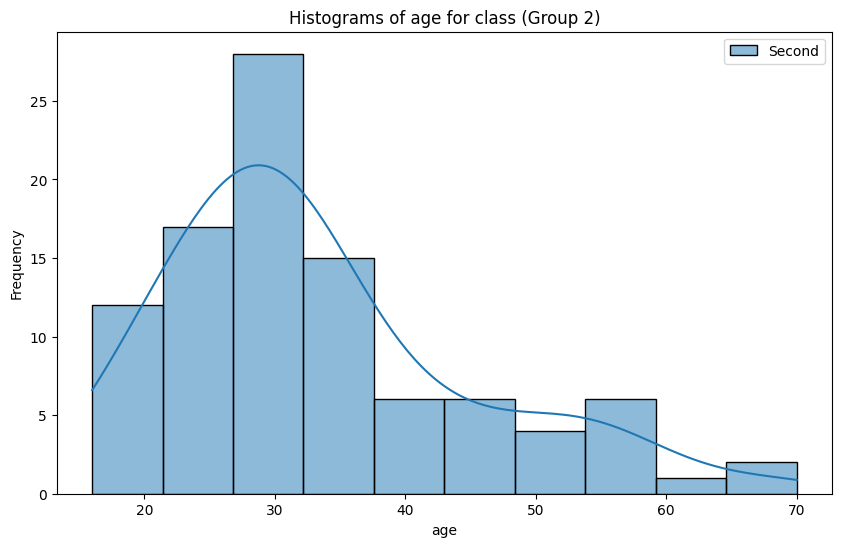

Respuesta yes:


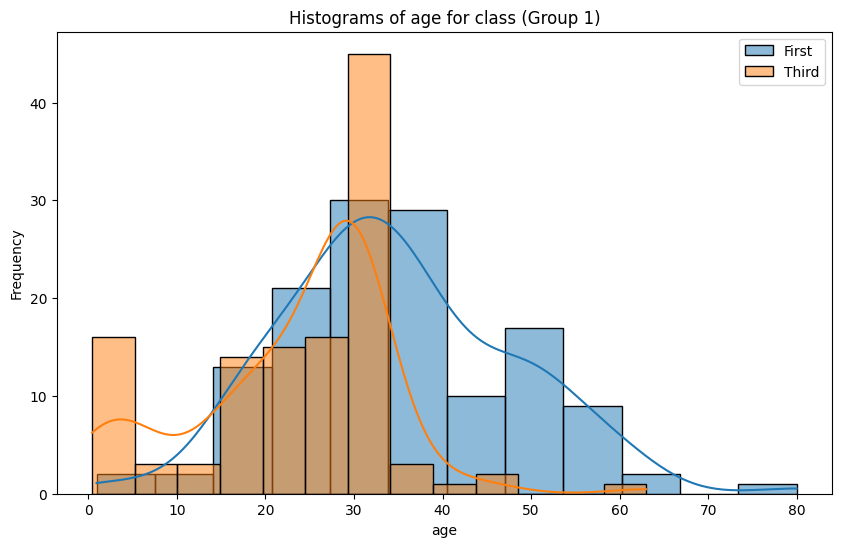

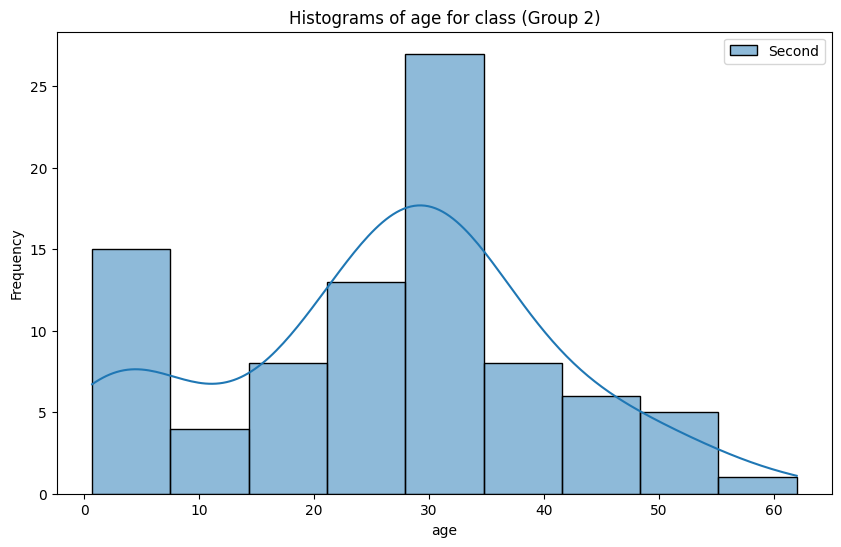

In [48]:
trivariant_analysis(df,"alive","class","age",group_size=2)

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?